|S|: 100 |A|: 5
opt_pi: [0 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Recovered Reward Function R(s): [1.  1.  1.  1.  1.  1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.9 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
Advantage Variables delta_s: [-0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.9         0.9         0.9
  0.9         0.9         0.9         0.9         0.9         0.9
  0.9        -0.          0.81        0.81        0.81        0.81
  0.81        0.81        0.81        0.81   

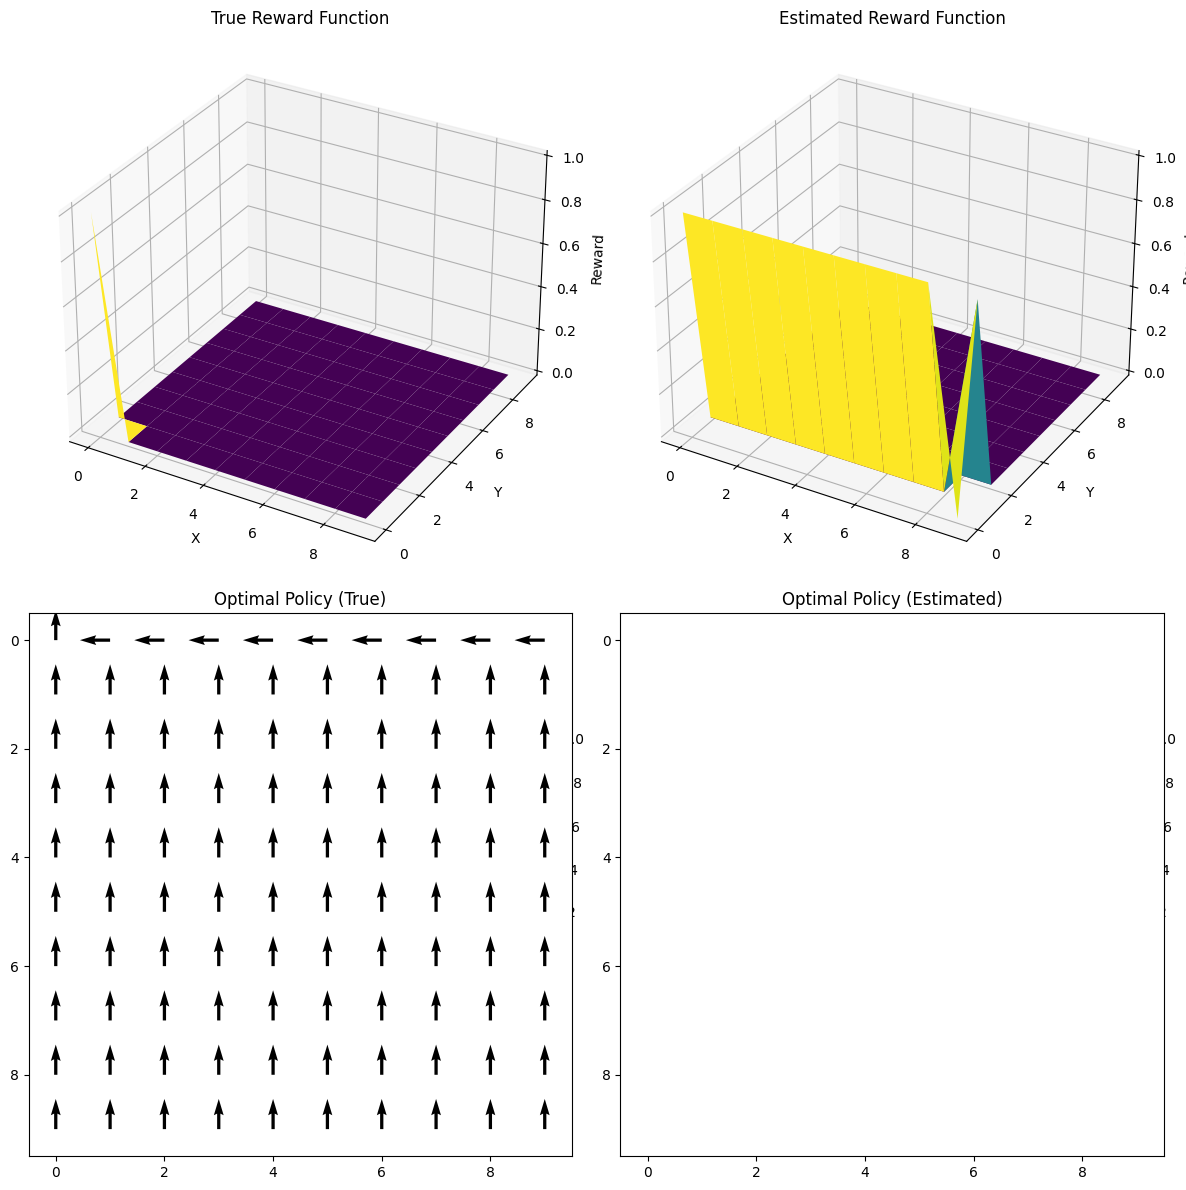

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from finite_lp_irl import finite_lp_irl, value_iteration

grid_size = 10
N = grid_size * grid_size
K = 5  # up, down, left, right, stay
gamma = 0.9
Rmax = 1.0
lp_lambda = 3

actions = ['up', 'down', 'left', 'right', 'stay']
action_indices = {action: i for i, action in enumerate(actions)}

# Transition probability matrix
P = np.zeros((N, K, N))
for s in range(N):
    x, y = divmod(s, grid_size)
    for a_idx, action in enumerate(actions):
        if action == 'up':
            next_x = x - 1
            next_y = y
        elif action == 'down':
            next_x = x + 1
            next_y = y
        elif action == 'left':
            next_x = x
            next_y = y - 1
        elif action == 'right':
            next_x = x
            next_y = y + 1
        elif action == 'stay':
            next_x = x
            next_y = y
        if 0 <= next_x < grid_size and 0 <= next_y < grid_size:
            next_s = next_x * grid_size + next_y
        else:
            next_s = s  # Stay in the same state if action leads out of bounds
        P[s, a_idx, next_s] = 1.0

# Reward function setup
true_R = np.zeros(N)
goal_state = 0  # Top-left corner (state 0)
true_R[goal_state] = 1.0

# Value iteration to find the optimal policy and value function
V_opt, opt_pi = value_iteration(P, true_R, gamma)
estimated_R, result = finite_lp_irl(opt_pi, P, gamma, Rmax, lp_lambda)

# Reshape rewards for plotting
true_R_grid = true_R.reshape((grid_size, grid_size))
estimated_R_grid = estimated_R.reshape((grid_size, grid_size))

# Prepare for quiver plot data (Optimal Policy)
action_to_vector = {
    'up': (0, 1),      # Positive y-direction is upward
    'down': (0, -1),   # Negative y-direction is downward
    'left': (-1, 0),   # Negative x-direction is left
    'right': (1, 0),   # Positive x-direction is right
    'stay': (0, 0)
}

U_true = np.zeros((grid_size, grid_size))
V_true = np.zeros((grid_size, grid_size))
U_estimated = np.zeros((grid_size, grid_size))
V_estimated = np.zeros((grid_size, grid_size))

for s in range(N):
    x, y = divmod(s, grid_size)
    action = opt_pi[s]
    dx, dy = action_to_vector[actions[action]]
    U_true[x, y] = dx
    V_true[x, y] = dy

# Plot the 2x2 grid of True and Estimated Reward with Policies
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': '3d'})

# True Reward
ax1 = axs[0, 0]
ax1.plot_surface(X, Y, true_R_grid, cmap='viridis')
ax1.set_title('True Reward Function')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Reward')

# Estimated Reward
ax2 = axs[0, 1]
ax2.plot_surface(X, Y, estimated_R_grid, cmap='viridis')
ax2.set_title('Estimated Reward Function')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Reward')

# True Policy
ax3 = fig.add_subplot(2, 2, 3)
ax3.quiver(X, Y, U_true, V_true)
ax3.set_title('Optimal Policy (True)')
ax3.set_aspect('equal')
ax3.set_xlim(-0.5, grid_size - 0.5)
ax3.set_ylim(-0.5, grid_size - 0.5)
ax3.invert_yaxis()

# Estimated Policy (No arrows computed for estimated in this case)
ax4 = fig.add_subplot(2, 2, 4)
ax4.quiver(X, Y, U_estimated, V_estimated)  # Use estimated policy if available
ax4.set_title('Optimal Policy (Estimated)')
ax4.set_aspect('equal')
ax4.set_xlim(-0.5, grid_size - 0.5)
ax4.set_ylim(-0.5, grid_size - 0.5)
ax4.invert_yaxis()

plt.tight_layout()
plt.show()
